In [ ]:
# Controlling cpu usage
import os
os.environ["NUMBA_NUM_THREADS"] = "6"
os.environ["OMP_NUM_THREADS"] = "6"
os.environ["MKL_NUM_THREADS"] = "6"

In [2]:
import scanpy as sc
import anndata as ad
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Use the raw data for evaluation
brain_vascular = sc.read_h5ad("../brain_vascular.h5ad")
adata = brain_vascular.raw.to_adata()

# Adding mitochondrial gene annotation
adata.var["mt"] = adata.var["feature_name"].str.upper().str.startswith("MT-")
# Calculating QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    inplace=True
)

adata_qc = adata[
    (adata.obs["n_genes_by_counts"] > 300) &
    (adata.obs["n_genes_by_counts"] < 8000) &
    (adata.obs["total_counts"] < 55000) &
    (adata.obs["pct_counts_mt"] < 15),
    :
].copy()

In [ ]:
# Test/train split
adata = adata_qc.copy()

# Split train/test
train_idx, test_idx = train_test_split(
    np.arange(adata.n_obs),
    test_size=0.2,
    random_state=42,
    stratify=adata.obs["author_cell_type"]
)

# Create train/test AnnData objects
adata_train = adata[train_idx].copy()
adata_test = adata[test_idx].copy()

# Mark train/test batch
adata_train.obs["str_batch"] = "0"
adata_test.obs["str_batch"] = "1"
adata_train.obs["batch_id"] = 0
adata_test.obs["batch_id"] = 1

In [ ]:
# Encode labels
# Use categories from full dataset so train/test mapping is consistent
celltype_categories = adata.obs["author_cell_type"].cat.categories

adata_train.obs["author_cell_type"] = adata_train.obs["author_cell_type"].cat.set_categories(celltype_categories)
adata_test.obs["author_cell_type"] = adata_test.obs["author_cell_type"].cat.set_categories(celltype_categories)

adata_train.obs["author_cell_type_id"] = adata_train.obs["author_cell_type"].cat.codes
adata_test.obs["author_cell_type_id"] = adata_test.obs["author_cell_type"].cat.codes

# Create mapping from cell type ID to name and vice versa
id2type = dict(enumerate(celltype_categories))
type2id = {v: k for k, v in id2type.items()}

num_types = len(celltype_categories)
print(f"Number of cell types: {num_types}")

Number of cell types: 15


In [6]:
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
from pathlib import Path
from tqdm.auto import tqdm
import json

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from scipy.sparse import issparse

import scgpt as scg
from scgpt.model import TransformerModel
from scgpt.tokenizer import tokenize_and_pad_batch, random_mask_value
from scgpt.tokenizer.gene_tokenizer import GeneVocab
from scgpt.preprocess import Preprocessor

/data/slurm/huangjr/envs/scInterBrain/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/slurm/huangjr/envs/scInterBrain/lib/python3.11/site-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/data/slurm/huangjr/envs/scInterBrain/lib/python3.11/site-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/data/slurm/huangjr/envs/scInterBrain/lib/python3.11/site-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.

In [ ]:
# Set hyperparameters and file paths
model_dir = Path("/data/slurm/huangjr/cmml/models/scGPT_human") 
model_config_file = model_dir / "args.json"
model_file = model_dir / "best_model.pt"
vocab_file = model_dir / "vocab.json"

pad_token = "<pad>"
special_tokens = [pad_token, "<cls>", "<eoc>"]

n_bins = 51
max_seq_len = 1200
input_style = "binned"
include_zero_gene = False

mask_ratio = 0.0
mask_value = -1
pad_value = -2

# settings for training
CLS = True # celltype classification objective
CCE = False
MVC = False
ECS = False
DAB = False
INPUT_BATCH_LABELS = False

batch_size = 64
eval_batch_size = 64
epochs = 1
lr = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Load scGPT vocabulary
vocab = GeneVocab.from_file(vocab_file)

for s in special_tokens:
    if s not in vocab:
        vocab.append_token(s)

vocab.set_default_index(vocab[pad_token])

# Mark genes that exist in pretrained vocabulary
adata_train.var["id_in_vocab"] = [
    1 if gene in vocab else -1 for gene in adata_train.var["names"]
]

genes_in_vocab = adata_train.var["id_in_vocab"] >= 0

# Filter to genes in vocab and ensure test set has same genes
adata_train = adata_train[:, genes_in_vocab].copy()
adata_test = adata_test[:, adata_train.var_names].copy()

genes = adata_train.var["names"].tolist()
gene_ids = np.array(vocab(genes), dtype=int)

print(f"Using {len(genes)} genes found in scGPT vocabulary.")

Using 21432 genes found in scGPT vocabulary.


In [10]:
# Preprocess with scGPT preprocessor
preprocessor = Preprocessor(
    use_key="X",
    filter_gene_by_counts=False,
    filter_cell_by_counts=False,
    normalize_total=1e4,
    result_normed_key="X_normed",
    log1p=True,            
    result_log1p_key="X_log1p",
    subset_hvg=False,
    hvg_flavor="seurat_v3",
    binning=n_bins,
    result_binned_key="X_binned",
)

preprocessor(adata_train, batch_key=None)
preprocessor(adata_test, batch_key=None)

input_layer_key = "X_binned"

scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Log1p transforming ...
scGPT - INFO - Binning data ...
scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Log1p transforming ...
scGPT - INFO - Binning data ...


In [11]:
# Convert AnnData to scGPT tokenized dataset
class SeqDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return self.data["gene_ids"].shape[0]

    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.data.items()}


def get_counts(adata_obj):
    X = adata_obj.layers[input_layer_key]
    return X.A if issparse(X) else X


def make_dataset(adata_obj):
    counts = get_counts(adata_obj)

    celltype_labels = adata_obj.obs["author_cell_type_id"].values.astype(int)
    batch_labels = adata_obj.obs["batch_id"].values.astype(int)

    tokenized = tokenize_and_pad_batch(
        counts,
        gene_ids,
        max_len=max_seq_len,
        vocab=vocab,
        pad_token=pad_token,
        pad_value=pad_value,
        append_cls=True,
        include_zero_gene=include_zero_gene,
    )

    input_values = random_mask_value(
        tokenized["values"],
        mask_ratio=mask_ratio,
        mask_value=mask_value,
        pad_value=pad_value,
    )

    data_pt = {
        "gene_ids": tokenized["genes"],
        "values": input_values,
        "target_values": tokenized["values"],
        "batch_labels": torch.from_numpy(batch_labels).long(),
        "celltype_labels": torch.from_numpy(celltype_labels).long(),
    }

    return SeqDataset(data_pt)


train_dataset = make_dataset(adata_train)
test_dataset = make_dataset(adata_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=eval_batch_size,
    shuffle=False,
    drop_last=False,
    num_workers=0,
)

In [ ]:
# Load and initialize pretrained scGPT model
with open(model_config_file, "r") as f:
    model_configs = json.load(f)

embsize = model_configs["embsize"]
nhead = model_configs["nheads"]
d_hid = model_configs["d_hid"]
nlayers = model_configs["nlayers"]
n_layers_cls = model_configs.get("n_layers_cls", 3)

ntokens = len(vocab)
num_batch_types = 2

model = TransformerModel(
    ntokens,
    embsize,
    nhead,
    d_hid,
    nlayers,
    nlayers_cls=n_layers_cls,
    n_cls=num_types,
    vocab=vocab,
    dropout=0.2,
    pad_token=pad_token,
    pad_value=pad_value,
    do_mvc=False,
    do_dab=False,
    use_batch_labels=False,
    num_batch_labels=num_batch_types,
    domain_spec_batchnorm=False,
    input_emb_style="continuous",
    n_input_bins=n_bins,
    cell_emb_style="cls",
    mvc_decoder_style="inner product",
    ecs_threshold=0.0,
    explicit_zero_prob=False,
    use_fast_transformer=False,
    fast_transformer_backend="flash",
    pre_norm=False,
)

# Load pretrained weights, only for matching keys and shapes
pretrained_dict = torch.load(model_file, map_location=device)
model_dict = model.state_dict()

pretrained_dict = {
    k: v for k, v in pretrained_dict.items()
    if k in model_dict and v.shape == model_dict[k].shape
}

model_dict.update(pretrained_dict)
model.load_state_dict(model_dict)

model.to(device)

TransformerModel(
  (encoder): GeneEncoder(
    (embedding): Embedding(60697, 512, padding_idx=60694)
    (enc_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (value_encoder): ContinuousValueEncoder(
    (dropout): Dropout(p=0.2, inplace=False)
    (linear1): Linear(in_features=1, out_features=512, bias=True)
    (activation): ReLU()
    (linear2): Linear(in_features=512, out_features=512, bias=True)
    (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-11): 12 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=512, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=512, out_features=512, bias=True)
        (norm1): LayerNorm((512,), eps=1e-05, el

In [13]:
# Freeze scGPT
model.eval()

for param in model.parameters():
    param.requires_grad = False

In [ ]:
# Extract scGPT embeddings
@torch.no_grad()
def extract_scgpt_embeddings(model, loader):
    model.eval()

    all_embeddings = []
    all_labels = []

    for batch in tqdm(loader, desc="Extracting embeddings", leave=False):
        input_gene_ids = batch["gene_ids"].to(device)
        input_values = batch["values"].to(device)
        labels = batch["celltype_labels"].cpu().numpy()

        src_key_padding_mask = input_gene_ids.eq(vocab[pad_token])

        output_dict = model(
            input_gene_ids,
            input_values,
            src_key_padding_mask=src_key_padding_mask,
            CLS=False,
            CCE=False,
            MVC=False,
            ECS=False,
        )

        # Try common scGPT output keys
        if "cell_emb" in output_dict:
            cell_emb = output_dict["cell_emb"]
        elif "cls_output" in output_dict:
            cell_emb = output_dict["cls_output"]
        elif "encoder_output" in output_dict:
            # CLS token is usually the first token
            cell_emb = output_dict["encoder_output"][:, 0, :]
        else:
            raise KeyError(
                f"Cannot find embedding in output_dict. Available keys: {output_dict.keys()}"
            )

        all_embeddings.append(cell_emb.cpu().numpy())
        all_labels.append(labels)

    all_embeddings = np.concatenate(all_embeddings, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return all_embeddings, all_labels

In [ ]:
# Extract embeddings for train and test sets
X_train_emb, y_train = extract_scgpt_embeddings(model, train_loader)
X_test_emb, y_test = extract_scgpt_embeddings(model, test_loader)

print(X_train_emb.shape)
print(X_test_emb.shape)

Extracting embeddings:   0%|          | 0/769 [00:00<?, ?it/s]/data/slurm/huangjr/envs/scInterBrain/lib/python3.11/site-packages/torch/nn/modules/transformer.py:408: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ../aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)
                                                                        

(49197, 512)
(12300, 512)


In [ ]:
from emb_eva import evaluate_embeddings
import pandas as pd

# Evaluate embeddings with logistic regression classifier
results = []
result, pred, clf = evaluate_embeddings(
    X_train_emb=X_train_emb,
    y_train=y_train,
    X_test_emb=X_test_emb,
    y_test=y_test,
    model_name="scGPT_frozen_embedding",
    classifier="logreg",
)
results.append(result)

benchmark_df = pd.DataFrame(results)
benchmark_df

/data/slurm/huangjr/envs/scInterBrain/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=4', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,model,classifier,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,n_train,n_test,embedding_dim
0,scGPT_frozen_embedding,logreg,0.933659,0.934467,0.94718,0.940056,0.935628,0.933659,0.934114,49197,12300,512


In [19]:
# Classification report
from sklearn.metrics import classification_report
import pandas as pd

class_names = list(celltype_categories.astype(str))
labels = np.arange(len(class_names))               

report = classification_report(
    y_test,
    pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
report_df

,precision,recall,f1-score,support
Arterial,0.905396,0.901605,0.903497,1433.000000
Astrocyte,0.968310,0.985663,0.976909,279.000000
Capillary,0.864241,0.802991,0.832491,1538.000000
Excitatory_Neuron,0.979832,0.979832,0.979832,595.000000
Inhibitory_Neuron,0.954545,0.981308,0.967742,321.000000
Meningeal_Fibroblast,0.973361,0.955734,0.964467,497.000000
Microglia,0.986584,0.970066,0.978255,1971.000000
Oligodendrocyte,0.993025,0.986147,0.989574,1155.000000
Oligodendrocyte_Precursor_Cell,1.000000,0.991228,0.995595,114.000000
Pericyte,0.930900,0.967480,0.948837,738.000000


In [20]:
report_df.to_csv("../metrics/scGPT_classification_report.csv")

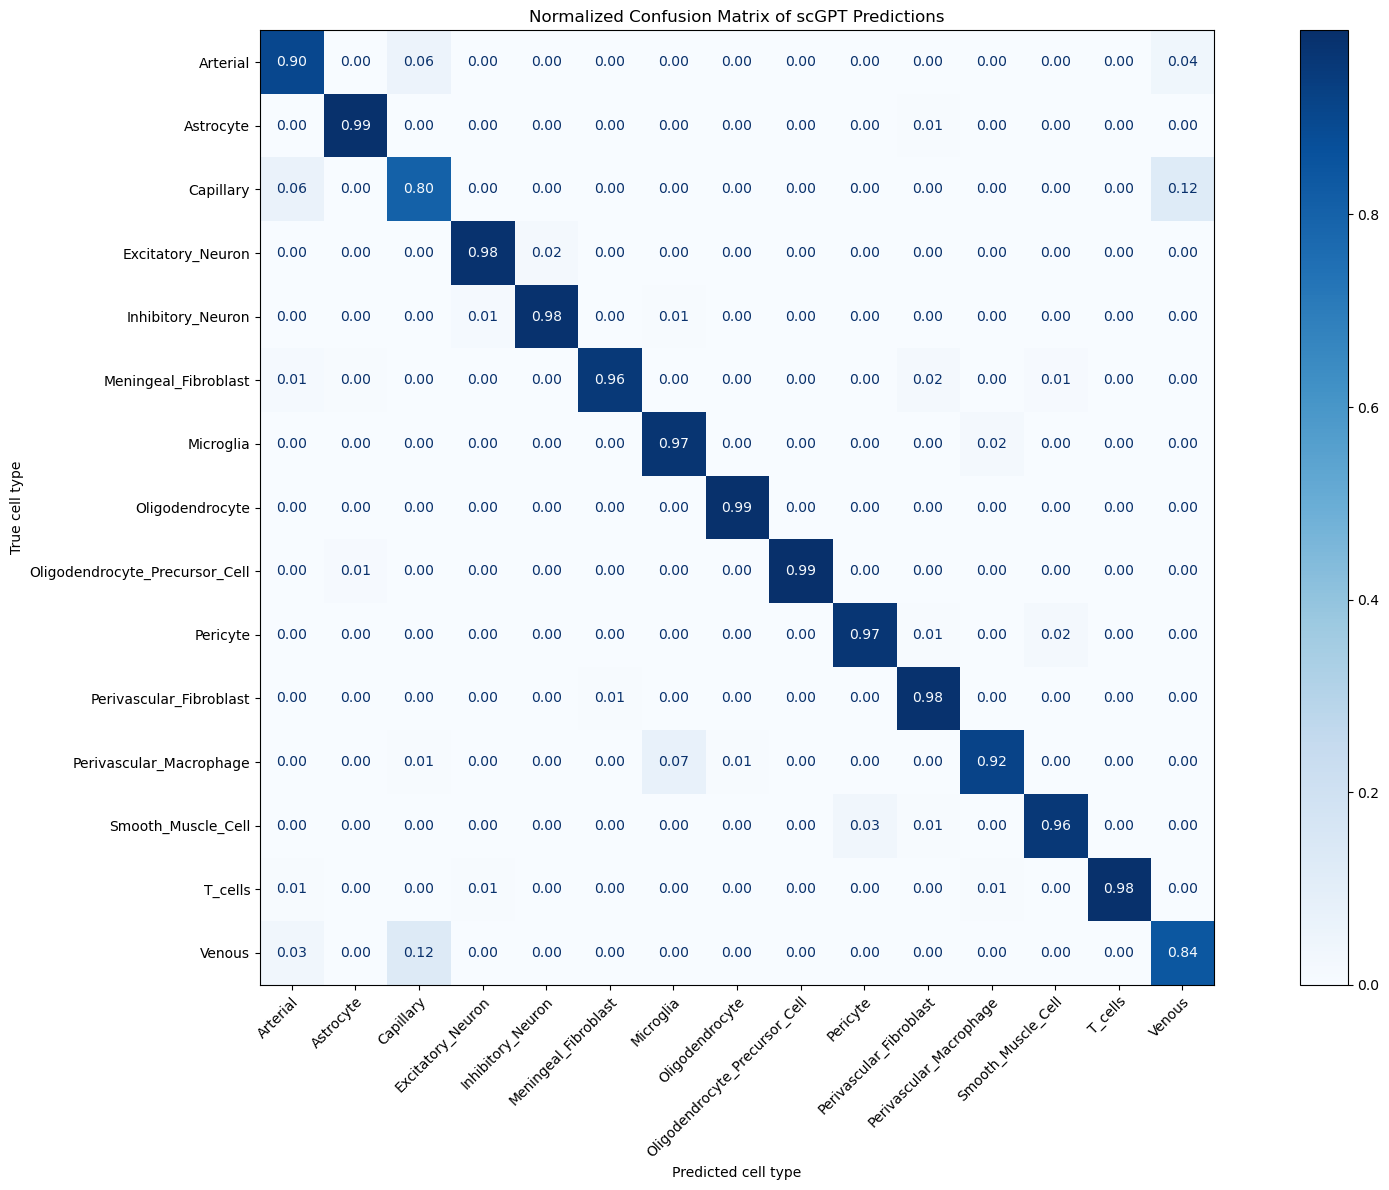

In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

# Map predicted and true labels back to cell type names for confusion matrix
class_names = list(celltype_categories.astype(str))
class_ids = np.arange(len(class_names))

# Normalize confusion matrix
cm_norm = confusion_matrix(
    y_test,
    pred,
    labels=class_ids,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(18, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format=".2f"
)

ax.set_title("Normalized Confusion Matrix of scGPT Predictions")
ax.set_xlabel("Predicted cell type")
ax.set_ylabel("True cell type")

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
    label.set_rotation_mode("anchor")

plt.tight_layout()
plt.savefig("normalized_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
